# K-means

In [47]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn import preprocessing

In [48]:
#Cargamos los datos
wine = pd.read_excel('./Data/wines_data.xlsx')
wine.head(5)

,Codigo,Alcohol,Acido Malico,Ceniza,Alcalinidad de ceniza,Magnesium,Compuesto fenolico,Flavonoides,Fenoles no flavonoides,Proantocianidinas,Intensidad del color,Matiz del vino,OD280,Prolina
0,VIN177,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,VIN176,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,VIN175,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,VIN174,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,VIN173,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [49]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Codigo                  177 non-null    object 
 1   Alcohol                 177 non-null    float64
 2   Acido Malico            177 non-null    float64
 3   Ceniza                  177 non-null    float64
 4   Alcalinidad de ceniza   177 non-null    float64
 5   Magnesium               177 non-null    int64  
 6   Compuesto fenolico      177 non-null    float64
 7   Flavonoides             177 non-null    float64
 8   Fenoles no flavonoides  177 non-null    float64
 9   Proantocianidinas       177 non-null    float64
 10  Intensidad del color    177 non-null    float64
 11  Matiz del vino          177 non-null    float64
 12  OD280                   177 non-null    float64
 13  Prolina                 177 non-null    int64  
dtypes: float64(11), int64(2), object(1)
memory

In [50]:
wine.describe()

,Alcohol,Acido Malico,Ceniza,Alcalinidad de ceniza,Magnesium,Compuesto fenolico,Flavonoides,Fenoles no flavonoides,Proantocianidinas,Intensidad del color,Matiz del vino,OD280,Prolina
count,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000
mean,13.001921,2.336045,2.367006,19.494915,99.819209,2.300226,2.037853,0.361186,1.596271,5.030734,0.959638,2.617232,748.457627
std,0.813943,1.120308,0.275045,3.349038,14.285286,0.623886,0.995087,0.124486,0.569464,2.295872,0.227341,0.708127,315.106457
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.360000,1.600000,2.210000,17.200000,88.000000,1.750000,1.220000,0.270000,1.250000,3.210000,0.790000,1.960000,502.000000
50%,13.050000,1.860000,2.360000,19.500000,98.000000,2.360000,2.140000,0.340000,1.560000,4.680000,0.970000,2.780000,675.000000
75%,13.680000,3.100000,2.560000,21.500000,107.000000,2.800000,2.880000,0.430000,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


Lo primero que debemos hacer es guarda el código de los vinos, ya que nos interesa saber que vinos quedó en cada grupo, pero no es una variable que se pueda utilizar en el modelo ya es que es un identificador, así que lo guardamos de la siguiente forma

In [51]:
labels = wine[['Codigo']]
wine.drop(['Codigo'], axis='columns',inplace=True)
display(wine.head(5))
labels.head(5)

,Alcohol,Acido Malico,Ceniza,Alcalinidad de ceniza,Magnesium,Compuesto fenolico,Flavonoides,Fenoles no flavonoides,Proantocianidinas,Intensidad del color,Matiz del vino,OD280,Prolina
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


,Codigo
0,VIN177
1,VIN176
2,VIN175
3,VIN174
4,VIN173


Luego, notamos que algunas variables como alcohol, prolina o Magnesio, están en una escala muy distinta a variables como fenoles no flavonoides, por lo que es necesario normalizar o estandarizar los datos. Lo anterior es importante porque K-Means se basa en la distancia Euclidiana y esta se ve afectada por valores en escalas tan distintas. Para esto utilizaremos la función `StandardScaler` que viene en el modulo de `sklearn`.

In [52]:
stand_fn = preprocessing.StandardScaler() #Tambien se puede usar el minmaxscaler
scaled_wine_df = pd.DataFrame(stand_fn.fit_transform(wine), columns = wine.columns)
scaled_wine_df.head(5)

,Alcohol,Acido Malico,Ceniza,Alcalinidad de ceniza,Magnesium,Compuesto fenolico,Flavonoides,Fenoles no flavonoides,Proantocianidinas,Intensidad del color,Matiz del vino,OD280,Prolina
0,1.513083,-0.560401,0.229683,-1.166295,1.908110,0.803338,1.030107,-0.654021,1.221669,0.266127,0.354487,1.844957,1.007407
1,0.244048,-0.497740,-0.827683,-2.483832,0.012692,0.562228,0.727771,-0.815137,-0.556959,-0.284241,0.398599,1.108542,0.959669
2,0.194765,0.021443,1.104744,-0.267974,0.082892,0.803338,1.211509,-0.492905,2.137399,0.283599,0.310376,0.782821,1.389311
3,1.685573,-0.345566,0.484909,-0.806966,0.925301,2.491112,1.463456,-0.976253,1.027957,1.209615,-0.439520,1.179352,2.328158
4,0.293331,0.227326,1.833962,0.450683,1.276304,0.803338,0.657226,0.232116,0.393991,-0.310449,0.354487,0.442937,-0.042829


In [53]:
scaled_wine_df.describe()

,Alcohol,Acido Malico,Ceniza,Alcalinidad de ceniza,Magnesium,Compuesto fenolico,Flavonoides,Fenoles no flavonoides,Proantocianidinas,Intensidad del color,Matiz del vino,OD280,Prolina
count,1.770000e+02,1.770000e+02,1.770000e+02,1.770000e+02,1.770000e+02,1.770000e+02,1.770000e+02,1.770000e+02,1.770000e+02,1.770000e+02,1.770000e+02,1.770000e+02,1.770000e+02
mean,-6.021549e-16,-1.605746e-16,-5.005412e-16,-1.003591e-15,-3.813647e-16,4.014366e-16,-1.204310e-16,-1.204310e-16,3.412211e-16,-6.021549e-17,2.408619e-16,-8.028731e-17,8.028731e-17
std,1.002837e+00,1.002837e+00,1.002837e+00,1.002837e+00,1.002837e+00,1.002837e+00,1.002837e+00,1.002837e+00,1.002837e+00,1.002837e+00,1.002837e+00,1.002837e+00,1.002837e+00
min,-2.429550e+00,-1.428690e+00,-3.671632e+00,-2.663496e+00,-2.093329e+00,-2.122136e+00,-1.711076e+00,-1.862390e+00,-2.089045e+00,-1.638321e+00,-2.115758e+00,-1.907925e+00,-1.497247e+00
25%,-7.908932e-01,-6.588664e-01,-5.724566e-01,-6.871901e-01,-8.297166e-01,-8.844351e-01,-8.242224e-01,-7.345789e-01,-6.097899e-01,-7.952968e-01,-7.483009e-01,-9.307596e-01,-7.843597e-01
50%,5.923694e-02,-4.261290e-01,-2.554322e-02,1.522578e-03,-1.277097e-01,9.608095e-02,1.029424e-01,-1.706735e-01,-6.387423e-02,-1.532008e-01,4.570651e-02,2.305096e-01,-2.337814e-01
75%,8.354428e-01,6.838495e-01,7.036746e-01,6.004032e-01,5.040964e-01,8.033385e-01,8.487054e-01,5.543476e-01,6.229230e-01,5.107352e-01,7.073793e-01,7.828206e-01,7.528040e-01
max,2.252326e+00,3.100738e+00,3.146554e+00,3.145646e+00,4.365134e+00,2.539334e+00,3.065839e+00,2.407179e+00,3.493383e+00,3.480975e+00,3.309959e+00,1.958252e+00,2.964665e+00


Con los datos estandarizados ya estamos listos para poder correr nuestro modelo de K-means. Para ello y como lo mencionamos antes, ocuparemos la función `KMeans`.

In [54]:
kmeans_model = KMeans(n_clusters=3,
                      random_state=2024)
kmeans_model.fit(scaled_wine_df)

KMeans(n_clusters=3, random_state=2024)

In [55]:
cluster_labels = kmeans_model.predict(scaled_wine_df)
print(kmeans_model)
print(cluster_labels)

KMeans(n_clusters=3, random_state=2024)
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 2 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


agregamos las etiquetas de los clusters en los datos

In [56]:
wine['cluster'] = cluster_labels
wine.head()

,Alcohol,Acido Malico,Ceniza,Alcalinidad de ceniza,Magnesium,Compuesto fenolico,Flavonoides,Fenoles no flavonoides,Proantocianidinas,Intensidad del color,Matiz del vino,OD280,Prolina,cluster
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2


Y ahora podemos calcular los centros originales, dado que `Kmeans` entrega los centros pero estandarizados, por lo que debemos volver a la escala normal.

In [57]:
pd.DataFrame(kmeans_model.cluster_centers_,columns = scaled_wine_df.columns)

,Alcohol,Acido Malico,Ceniza,Alcalinidad de ceniza,Magnesium,Compuesto fenolico,Flavonoides,Fenoles no flavonoides,Proantocianidinas,Intensidad del color,Matiz del vino,OD280,Prolina
0,-0.925284,-0.392664,-0.495047,0.170131,-0.497073,-0.084443,0.012241,-0.028148,0.049102,-0.898785,0.454654,0.263627,-0.758361
1,0.171848,0.885794,0.194681,0.533329,-0.063125,-0.981201,-1.222299,0.726742,-0.775326,0.939411,-1.170007,-1.301799,-0.402328
2,0.831468,-0.302686,0.362001,-0.608466,0.572033,0.879820,0.972891,-0.556572,0.573785,0.184685,0.466900,0.773456,1.119514


In [58]:
centers_kmeans = wine.groupby(['cluster']).aggregate('mean').reset_index()
centers_kmeans

,cluster,Alcohol,Acido Malico,Ceniza,Alcalinidad de ceniza,Magnesium,Compuesto fenolico,Flavonoides,Fenoles no flavonoides,Proantocianidinas,Intensidad del color,Matiz del vino,OD280,Prolina
0,0,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231
1,1,13.141400,3.325600,2.420400,21.276000,98.920000,1.689800,0.825000,0.451400,1.156000,7.181400,0.694400,1.698000,622.040000
2,2,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806


podemos revisar cuantos elementos quedaron en cada clusters

In [59]:
wine.groupby(['cluster'])['cluster'].count()

cluster
0    65
1    50
2    62
Name: cluster, dtype: int64

y finalmente, algunas gráficas para tener alguna idea de como esta funcionando nuestra segmentación. Para eso utilizaremos algunos scatter plot de algunos pares de variables y los colorearemos según su cluster. Además agregaremos donde se encuentra el centro de los clusters para ese par de variables

In [60]:
import matplotlib.pyplot as plt

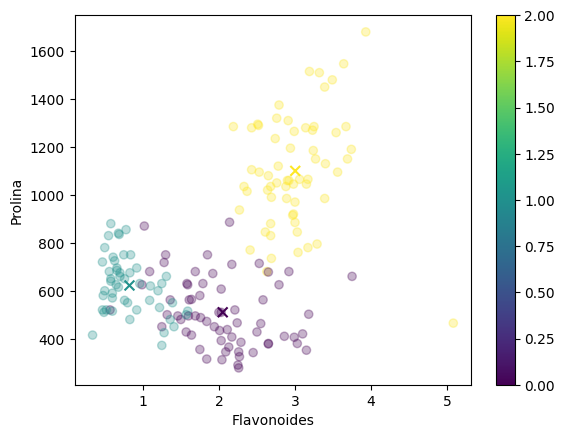

In [61]:
#Graficamos Flavonoides vs Prolina
plt.scatter(wine.Flavonoides, wine.Prolina, c = wine.cluster, alpha = 0.3)
plt.scatter(centers_kmeans.Flavonoides,centers_kmeans.Prolina,c = centers_kmeans.cluster, marker = 'x', s = 50) 
plt.xlabel('Flavonoides')
plt.ylabel('Prolina')
plt.colorbar()

In [62]:
wine['Intensidad del color']

0       5.64
1       4.38
2       5.68
3       7.80
4       4.32
       ...  
172     7.70
173     7.30
174    10.20
175     9.30
176     9.20
Name: Intensidad del color, Length: 177, dtype: float64

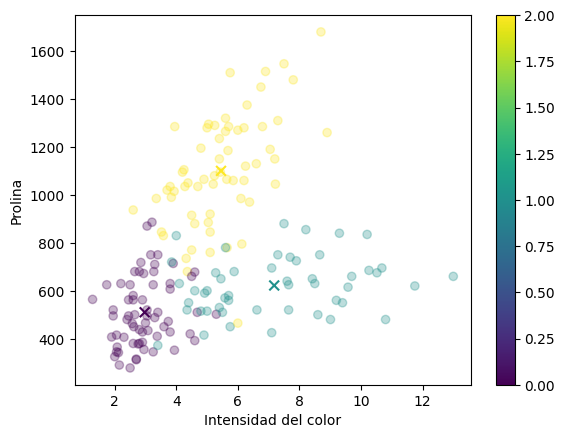

In [63]:
#Graficamos Flavonoides vs Prolina
plt.scatter(wine['Intensidad del color'], wine.Prolina, c = wine.cluster, alpha = 0.3)
plt.scatter(centers_kmeans['Intensidad del color'],centers_kmeans.Prolina,c = centers_kmeans.cluster, marker = 'x', s = 50) 
plt.xlabel('Intensidad del color')
plt.ylabel('Prolina')
plt.colorbar()

In [64]:
wine.groupby(['cluster']).aggregate(['mean','median','min','max'])

Alcohol                       Acido Malico                     \
              mean  median    min    max         mean median   min   max   
cluster                                                                    
0        12.250923  12.250  11.03  13.86     1.897385  1.610  0.74  5.80   
1        13.141400  13.135  12.20  14.34     3.325600  3.285  1.24  5.65   
2        13.676774  13.735  11.56  14.83     1.997903  1.765  1.35  4.04   

           Ceniza         ... Matiz del vino           OD280               \
             mean median  ...            min   max      mean median   min   
cluster                   ...                                               
0        2.231231  2.240  ...           0.69  1.71  2.803385   2.84  1.67   
1        2.420400  2.380  ...           0.48  0.98  1.698000   1.68  1.27   
2        2.466290  2.445  ...           0.82  1.31  3.163387   3.17  2.51   

                   Prolina                     
          max         mean  median  min   max  
cluster                                        
0        3.64   510.169231   495.0  278   886  
1        2.47   622.040000   622.5  372   880  
2        4.00  1100.225806  1072.5  465  1680  

[3 rows x 52 columns]

# K-Modes

In [65]:
#Volvemos a cargar los datos
wine = pd.read_excel('./Data/wines_data.xlsx')

#ahora creamos las variables categóricas
wine['alcohol_cat'] = np.where(wine['Alcohol'] < 13, 'low', 'high')
wine['flavonoides_cat'] = np.where(wine['Flavonoides'] < 1.5, "very low",np.where(wine['Flavonoides'] < 3, 'normal','anormal'))
wine['intensidad_cat'] = np.where(wine['Intensidad del color'] < 4, 'low color',np.where(wine['Intensidad del color'] < 6.5, 'normal','strong color'))

wine_cat = wine[['alcohol_cat','flavonoides_cat','intensidad_cat']]
wine_cat.head(20)

,alcohol_cat,flavonoides_cat,intensidad_cat
0,high,anormal,normal
1,high,normal,normal
2,high,anormal,normal
3,high,anormal,strong color
4,high,normal,normal
5,high,anormal,strong color
6,high,normal,normal
7,high,normal,normal
8,high,normal,normal
9,high,anormal,strong color


Uno de los problemas que tiene Python (versus otros lenguajes utilizados en ciencia de datos como R) es que no es bueno manejando categorías en los datos, por ello debemos utilizar algun tipo de encoder para que los modelos puedan utilizar este tipo de variables. En este caso, el modulo de `preprocessing` tiene una función que se llama `LabelEncoder` que utilizaremos ahora.

In [66]:
labels_cat = preprocessing.LabelEncoder()
wine_cat_enc = wine_cat.apply(labels_cat.fit_transform)
wine_cat_enc.head(5)

,alcohol_cat,flavonoides_cat,intensidad_cat
0,0,0,1
1,0,1,1
2,0,0,1
3,0,0,2
4,0,1,1


y ahora podemos ajustar el modelo. Al igual que en el caso anterior, daremos por sabido que $K=4$ porque aun no tenemos las herramientas para determinar el número de clusters.

In [67]:
#importamos el modulo correspondiente
from kmodes.kmodes import KModes

In [68]:
kmodes_model = KModes(n_clusters=4, 
                      random_state=2024)
cluster_labels = kmodes_model.fit_predict(wine_cat_enc)
print(kmodes_model)
print(cluster_labels)

KModes(n_clusters=4, n_init=1, random_state=2024)
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 2 2 2 2 2 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 1 0 1 0 0 2 0 3 0 0 0 0 0
 0 0 2 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1
 3 3 3 1 3 3 1 3 3 1 3 3 1 1 1 1 3 3 3 1 3 3 1 3 3 3 3 3 3]


In [69]:
#miramos los centros
cluster_centroids_df = pd.DataFrame(kmodes_model.cluster_centroids_, columns=wine_cat_enc.columns)
display(cluster_centroids_df)

,alcohol_cat,flavonoides_cat,intensidad_cat
0,1,1,0
1,1,2,1
2,0,0,1
3,0,2,2


ahora agregamos los clusters a los datos originales para ver como se están comportando

In [70]:
wine_cat['cluster'] = cluster_labels

/var/folders/7q/j3kpp1td16jbzr0w1mzy1lym0000gn/T/ipykernel_23720/2943050613.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wine_cat['cluster'] = cluster_labels


In [71]:
display(wine_cat.query('cluster == 0')['intensidad_cat'].value_counts('%'))
display(wine_cat.query('cluster == 1')['intensidad_cat'].value_counts('%'))
display(wine_cat.query('cluster == 2')['intensidad_cat'].value_counts('%'))
display(wine_cat.query('cluster == 3')['intensidad_cat'].value_counts('%'))

intensidad_cat
low color    0.958333
normal       0.041667
Name: proportion, dtype: float64

intensidad_cat
normal          0.733333
strong color    0.266667
Name: proportion, dtype: float64

intensidad_cat
normal          0.792453
strong color    0.207547
Name: proportion, dtype: float64

intensidad_cat
strong color    0.954545
low color       0.045455
Name: proportion, dtype: float64

In [72]:
display(wine_cat.query('cluster == 0')['alcohol_cat'].value_counts('%'))
display(wine_cat.query('cluster == 1')['alcohol_cat'].value_counts('%'))
display(wine_cat.query('cluster == 2')['alcohol_cat'].value_counts('%'))
display(wine_cat.query('cluster == 3')['alcohol_cat'].value_counts('%'))

alcohol_cat
low     0.861111
high    0.138889
Name: proportion, dtype: float64

alcohol_cat
low     0.766667
high    0.233333
Name: proportion, dtype: float64

alcohol_cat
high    1.0
Name: proportion, dtype: float64

alcohol_cat
high    1.0
Name: proportion, dtype: float64

In [73]:
display(wine_cat.query('cluster == 0')['flavonoides_cat'].value_counts('%'))
display(wine_cat.query('cluster == 1')['flavonoides_cat'].value_counts('%'))
display(wine_cat.query('cluster == 2')['flavonoides_cat'].value_counts('%'))
display(wine_cat.query('cluster == 3')['flavonoides_cat'].value_counts('%'))

flavonoides_cat
normal      0.819444
very low    0.152778
anormal     0.027778
Name: proportion, dtype: float64

flavonoides_cat
very low    0.9
anormal     0.1
Name: proportion, dtype: float64

flavonoides_cat
anormal    0.528302
normal     0.471698
Name: proportion, dtype: float64

flavonoides_cat
very low    0.909091
normal      0.090909
Name: proportion, dtype: float64

In [74]:
display(wine_cat.query('cluster == 1')['alcohol_cat'].value_counts('%'))
display(wine_cat.query('cluster == 2')['alcohol_cat'].value_counts('%'))
display(wine_cat.query('cluster == 3')['flavonoides_cat'].value_counts('%'))
display(wine_cat.query('cluster == 2')['flavonoides_cat'].value_counts('%'))
display(wine_cat.query('cluster == 2')['intensidad_cat'].value_counts('%'))

alcohol_cat
low     0.766667
high    0.233333
Name: proportion, dtype: float64

alcohol_cat
high    1.0
Name: proportion, dtype: float64

flavonoides_cat
very low    0.909091
normal      0.090909
Name: proportion, dtype: float64

flavonoides_cat
anormal    0.528302
normal     0.471698
Name: proportion, dtype: float64

intensidad_cat
normal          0.792453
strong color    0.207547
Name: proportion, dtype: float64

In [75]:
display(wine_cat.query('cluster == 2')['alcohol_cat'].value_counts('%'))
display(wine_cat.query('cluster == 2')['flavonoides_cat'].value_counts('%'))
display(wine_cat.query('cluster == 2')['intensidad_cat'].value_counts('%'))

alcohol_cat
high    1.0
Name: proportion, dtype: float64

flavonoides_cat
anormal    0.528302
normal     0.471698
Name: proportion, dtype: float64

intensidad_cat
normal          0.792453
strong color    0.207547
Name: proportion, dtype: float64

In [76]:
display(wine_cat.query('cluster == 1')['alcohol_cat'].value_counts('%'))
display(wine_cat.query('cluster == 1')['flavonoides_cat'].value_counts('%'))
display(wine_cat.query('cluster == 1')['intensidad_cat'].value_counts('%'))

alcohol_cat
low     0.766667
high    0.233333
Name: proportion, dtype: float64

flavonoides_cat
very low    0.9
anormal     0.1
Name: proportion, dtype: float64

intensidad_cat
normal          0.733333
strong color    0.266667
Name: proportion, dtype: float64

# K-Prototype

In [77]:
wine.head()

,Codigo,Alcohol,Acido Malico,Ceniza,Alcalinidad de ceniza,Magnesium,Compuesto fenolico,Flavonoides,Fenoles no flavonoides,Proantocianidinas,Intensidad del color,Matiz del vino,OD280,Prolina,alcohol_cat,flavonoides_cat,intensidad_cat
0,VIN177,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,high,anormal,normal
1,VIN176,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,high,normal,normal
2,VIN175,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,high,anormal,normal
3,VIN174,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,high,anormal,strong color
4,VIN173,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,high,normal,normal


In [78]:
wine_num = scaled_wine_df[['Ceniza','Matiz del vino']]
wine_proto = pd.concat([wine_num,wine_cat_enc], axis = 1)
wine_proto.head()

,Ceniza,Matiz del vino,alcohol_cat,flavonoides_cat,intensidad_cat
0,0.229683,0.354487,0,0,1
1,-0.827683,0.398599,0,1,1
2,1.104744,0.310376,0,0,1
3,0.484909,-0.439520,0,0,2
4,1.833962,0.354487,0,1,1


In [79]:
wine_num_2 = wine[['Ceniza','Prolina']]
wine_proto_2 = pd.concat([wine_num_2,wine_cat_enc], axis = 1)
wine_proto_2.head()

,Ceniza,Prolina,alcohol_cat,flavonoides_cat,intensidad_cat
0,2.43,1065,0,0,1
1,2.14,1050,0,1,1
2,2.67,1185,0,0,1
3,2.50,1480,0,0,2
4,2.87,735,0,1,1


In [80]:
wine_proto_2.describe()

,Ceniza,Prolina,alcohol_cat,flavonoides_cat,intensidad_cat
count,177.000000,177.000000,177.000000,177.000000,177.000000
mean,2.367006,748.457627,0.480226,1.141243,0.830508
std,0.275045,315.106457,0.501026,0.704970,0.772081
min,1.360000,278.000000,0.000000,0.000000,0.000000
25%,2.210000,502.000000,0.000000,1.000000,0.000000
50%,2.360000,675.000000,0.000000,1.000000,1.000000
75%,2.560000,985.000000,1.000000,2.000000,1.000000
max,3.230000,1680.000000,1.000000,2.000000,2.000000


ahora con la función `KPrototypes` ajustaremos el modelo

In [81]:
from kmodes.kprototypes import KPrototypes

kprototype_model = KPrototypes(n_clusters = 3,
                               random_state=2024)
kprototype_model.fit(wine_proto, categorical = [2,3,4])

KPrototypes(gamma=np.float64(0.49999999999999994), n_clusters=3,
            random_state=2024)

La unica diferencia con los ajustes anteriores, es que al momento de entregarle los datos, debemos indicarle al modelo cuales son las variables categóricas. Así el modelo podrá diferenciarlas y ocupar las medidas de distancias correctas en cada caso (note que al tener las variables codificadas con números, sin esta indicación no tendría el modelo como hacer la diferencia).

In [82]:
cluster_labels = kprototype_model.predict(wine_proto, categorical = [2,3,4])
cluster_labels

array([2, 1, 2, 0, 2, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 1, 2, 0,
       1, 2, 2, 1, 2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 0, 1, 1, 1, 1, 1, 2, 2,
       1, 1, 2, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 0, 1, 1, 2,
       2, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 0, 2, 2, 0, 0, 1, 0, 2, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0], dtype=uint16)

In [83]:
kprototype_model = KPrototypes(n_clusters = 3, gamma = 0.6,random_state=2024)
kprototype_model.fit(wine_proto, categorical = [2,3,4])
cluster_labels = kprototype_model.predict(wine_proto, categorical = [2,3,4])
cluster_labels

array([0, 2, 0, 1, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 1,
       2, 0, 0, 2, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 2, 2, 0, 0,
       2, 2, 0, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 1, 1, 2, 2, 0,
       0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 0,
       2, 2, 0, 0, 0, 2, 2, 2, 2, 2, 1, 0, 0, 1, 1, 2, 1, 0, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1], dtype=uint16)

revisando lo anterior de manera gráfica

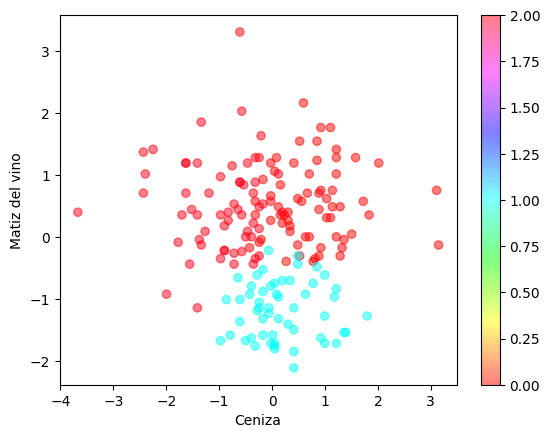

In [95]:
wine_proto['cluster'] = cluster_labels

plt.scatter(wine_proto['Ceniza'], wine_proto['Matiz del vino'], c = wine_proto.cluster, cmap='hsv', alpha = 0.5)
#plt.scatter(experiment_df_2['Intensidad del color'], experiment_df_2.Prolina, c = experiment_df_2.cluster, cmap='hsv', alpha = 0.5)

plt.xlabel('Ceniza')
plt.ylabel('Matiz del vino')
plt.colorbar()

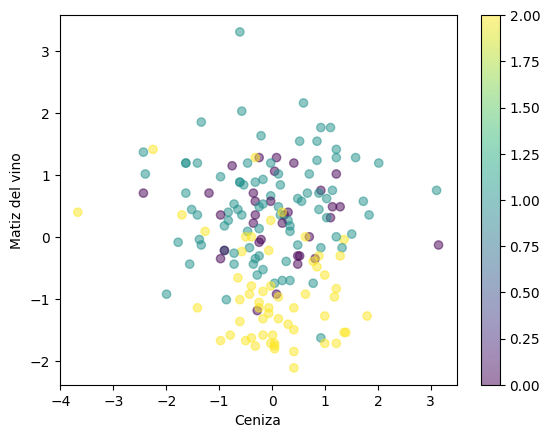

In [96]:
plt.scatter(wine_proto['Ceniza'], wine_proto['Matiz del vino'], c = wine_proto['flavonoides_cat'], alpha = 0.5)
plt.xlabel('Ceniza')
plt.ylabel('Matiz del vino')
plt.colorbar()

In [97]:
display(wine_proto.query('cluster == 0')['alcohol_cat'].value_counts('%'))
display(wine_proto.query('cluster == 1')['alcohol_cat'].value_counts('%'))
display(wine_proto.query('cluster == 2')['flavonoides_cat'].value_counts('%'))
display(wine_proto.query('cluster == 1')['intensidad_cat'].value_counts('%'))

alcohol_cat
0    0.723077
1    0.276923
Name: proportion, dtype: float64

alcohol_cat
0    0.555556
1    0.444444
Name: proportion, dtype: float64

flavonoides_cat
1    0.689655
2    0.172414
0    0.137931
Name: proportion, dtype: float64

intensidad_cat
2    0.555556
1    0.296296
0    0.148148
Name: proportion, dtype: float64

# Fuzzy C-Means

In [101]:
#pip install fuzzy-c-means
pip install fuzzy-cmeans

SyntaxError: invalid syntax (1087646038.py, line 2)

In [102]:
import sys
!pip list | grep fuzzy

fuzzy-c-means       1.7.2


In [103]:
from fcmeans import FCM

ImportError: cannot import name 'TypeIs' from 'typing_extensions' (/Users/miguel/Library/Python/3.9/lib/python/site-packages/typing_extensions.py)

In [ ]:
fcm_model = FCM(n_clusters = 3, random_state=2024)
fcm_model.fit(np.array(scaled_wine_df))

In [ ]:
fcm_model.predict(np.array(scaled_wine_df))

In [ ]:
print(cluster_labels)

Notemos que el modelo tal como lo corrimos es muy similar a lo que hace K-means, de hecho podemos graficarlo

In [ ]:
wine_fuzzy = pd.read_excel('./Data/wines_data.xlsx')
wine_fuzzy['cluster'] = fcm_model.predict(np.array(scaled_wine_df))

plt.scatter(wine_fuzzy['Intensidad del color'], wine_fuzzy.Prolina, c = wine_fuzzy.cluster, alpha = 0.5)
plt.xlabel('Intensidad del color')
plt.ylabel('Prolina')
plt.colorbar()

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharey = True, figsize = (15,5))
fig.suptitle('Comparison Fuzzy C-Means vs K-Means')
ax1.scatter(wine_fuzzy['Intensidad del color'], wine_fuzzy.Prolina, c = wine_fuzzy.cluster, alpha = 0.5)
ax2.scatter(wine['Intensidad del color'], wine.Prolina, c = wine_fuzzy.cluster, alpha = 0.5)

hagamos un experimento

In [ ]:
fcm_model.u

In [ ]:
prob_array = fcm_model.u
prob_df = pd.DataFrame(prob_array)
prob_cluster = prob_df.max(axis='columns')
label_cluster = prob_df.idxmax(axis = 1)
new_clusters_df = pd.concat([label_cluster,prob_cluster],axis = 1)
new_clusters_df.columns = ['Cluster','Probability']
print(new_clusters_df)

In [ ]:
new_clusters_df.head(20)

In [ ]:
new_clusters_df['Cluster'] = np.where(new_clusters_df['Probability'] < 0.7, -1,new_clusters_df['Cluster'])
new_clusters_df.head(30)

In [ ]:
new_clusters_df.head(20)

In [ ]:
experiment_df = pd.read_excel('./Data/wines_data.xlsx')
experiment_df['cluster'] = new_clusters_df['Cluster']
experiment_df.query('cluster > -0.5',inplace=True)
experiment_df.head(20)

In [ ]:
experiment_df.shape

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharey = True, figsize = (15,5))
fig.suptitle('Comparison Fuzzy C-Means vs K-Means')
ax1.scatter(experiment_df['Intensidad del color'], experiment_df.Prolina, c = experiment_df.cluster, alpha = 0.5)
ax2.scatter(wine['Intensidad del color'], wine.Prolina, c = wine_fuzzy.cluster, alpha = 0.5)

In [ ]:
experiment_df_2 = scaled_wine_df[['Intensidad del color','Prolina']]
experiment_df_2.head()

In [ ]:
fcm_model = FCM(n_clusters=3, random_state=2024)
fcm_model.fit(np.array(experiment_df_2))

In [ ]:
experiment_df_2['cluster'] = fcm_model.predict(np.array(experiment_df_2))
experiment_df_2.head()

In [ ]:
plt.scatter(experiment_df_2['Intensidad del color'], experiment_df_2.Prolina, c = experiment_df_2.cluster, alpha = 0.5)
plt.xlabel('Intensidad del color')
plt.ylabel('Prolina')
plt.colorbar()

In [ ]:
prob_array = fcm_model.u
prob_df = pd.DataFrame(prob_array)
prob_cluster = prob_df.max(axis='columns')
label_cluster = prob_df.idxmax(axis = 1)
new_clusters_df = pd.concat([label_cluster,prob_cluster],axis = 1)
new_clusters_df.columns = ['Cluster','Probability']
print(new_clusters_df)

In [ ]:
experiment_df_2['cluster'] = np.where(new_clusters_df['Probability'] < 0.8, 3,new_clusters_df['Cluster'])
experiment_df_2.head()

In [ ]:
experiment_df_2.head()

In [ ]:
exp_df_3 = experiment_df_2.query('cluster < 3',inplace=False)

In [ ]:
exp_df_3.shape

In [ ]:
plt.scatter(exp_df_3['Intensidad del color'], exp_df_3.Prolina, c = exp_df_3.cluster, alpha = 0.5)
plt.xlabel('Intensidad del color')
plt.ylabel('Prolina')
plt.colorbar()

In [ ]:
plt.scatter(experiment_df_2['Intensidad del color'], experiment_df_2.Prolina, c = experiment_df_2.cluster, alpha = 0.5)
plt.xlabel('Intensidad del color')
plt.ylabel('Prolina')
plt.colorbar()

In [ ]:
plt.scatter(experiment_df_2['Intensidad del color'], experiment_df_2.Prolina, c = experiment_df_2.cluster, alpha = 0.5)
plt.xlabel('Intensidad del color')
plt.ylabel('Prolina')
plt.colorbar()

# DBSCAN

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

In [ ]:
# 1. Generamos un dataset sintético no lineal
X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

In [ ]:
db = DBSCAN(eps=0.2, min_samples=5)
labels = db.fit_predict(X)

In [ ]:
plt.figure(figsize=(8, 6))
plt.title("Clustering con DBSCAN")
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="plasma", s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

In [ ]:
#comparación con K-means
k_means_comparison = KMeans(n_clusters=2)
k_means_comparison.fit(X)

In [ ]:
labels_km = k_means_comparison.predict(X)

In [ ]:
fig, ax = plt.subplots(ncols = 2, sharey = True, figsize=(8, 4))
ax[0].scatter(X[:, 0], X[:, 1], c=labels, cmap="plasma", s=50)
ax[0].set_title("DBSCAN", fontsize=14)
ax[0].set_xlabel("Feature 1")
ax[0].set_ylabel("Feature 2")
ax[1].scatter(X[:, 0], X[:, 1], c=labels_km, cmap="plasma", s=50)
ax[1].set_title("KMeans", fontsize=14)
ax[1].set_xlabel("Feature 1")

plt.show()

In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

iris = load_iris()
X = iris.data
X_scaled = StandardScaler().fit_transform(X)

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
#DBSCAN
db = DBSCAN(eps=0.5, min_samples=5)
labels_db = db.fit_predict(X_pca)

#KMeans
km = KMeans(n_clusters=3, random_state=42)
labels_km = km.fit_predict(X_pca)

In [ ]:
# Silhouette Score (validar que haya más de un clúster válido)
def safe_silhouette(X, labels):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    return silhouette_score(X, labels) if n_clusters > 1 else -1

score_db = safe_silhouette(X_pca, labels_db)
score_km = safe_silhouette(X_pca, labels_km)

In [ ]:
fig, ax = plt.subplots(ncols=2, sharey=True, figsize=(10, 4))

# DBSCAN
ax[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_db, cmap="plasma", s=50)
ax[0].set_title(f"DBSCAN\nSilhouette: {score_db:.2f}")
ax[0].set_xlabel("PCA 1")
ax[0].set_ylabel("PCA 2")

# KMeans
ax[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km, cmap="plasma", s=50)
ax[1].set_title(f"KMeans\nSilhouette: {score_km:.2f}")
ax[1].set_xlabel("PCA 1")

# Título general
fig.suptitle("Segmentación del dataset Iris: DBSCAN vs KMeans", fontsize=16)
plt.tight_layout()
plt.show()